In [1]:
import sys
try:
    import pyLOM
except ImportError as e:
    print(f'Error importing pyLOM: {e}')
    print('Importing with local repository')
    sys.path.append('/home/m.jaraiz/repos/pyLowOrder/')
from FotR import FRODO, SAM

def read_db_CODA(datafolder, case_idx):
    db = FRODO(root_dir = datafolder, format = 'CODA', initial_parse = True)
    
    db.extract_inputs(
        id_groups = (3,),
        cases_idx = case_idx,
        vtu_type='surface',
        verbose=False
        )

    for stage in [0, 1]:
        db.extract_outputs(
            id_groups=(3,),
            stage=stage, cases_idx = case_idx,
            var_name_excluded = [
                'BoundaryValues_CoefSkinFrictionX',
                'BoundaryValues_CoefSkinFrictionY',
                'BoundaryValues_CoefSkinFrictionZ'
                ],
            vtu_type='surface',
            )
    
    return db

def read_db_PYLOM(datafolder):
    db0 = FRODO(root_dir = datafolder, format = 'PYLOM', file = 'CADGroup_3_completo_stage_0.h5', initial_parse = True)

    db0.extract_inputs(
        keys_inputs={
            'ptos': 'xyz',    # coordenadas del mallado → data_dict['inputs']['ptos']
            'aoa': 'aoa',   # variable paramétrica   → data_dict['inputs']['aoa']
            'mach': 'M',   # variable paramétrica   → data_dict['inputs']['M']
        },
        keys_aux={},
    )

    db0.extract_outputs(
        keys_outputs={'cp': 'BoundaryValues_CoefPressure'}  # field del Dataset → data_dict['outputs']['cp']
    )

    db1 = FRODO(root_dir = datafolder, format = 'PYLOM', file = 'CADGroup_3_completo_stage_1.h5', initial_parse = True)

    db1.extract_inputs(
        keys_inputs={
            'ptos': 'xyz',    # coordenadas del mallado → data_dict['inputs']['ptos']
            'aoa': 'aoa',   # variable paramétrica   → data_dict['inputs']['aoa']
            'mach': 'M',   # variable paramétrica   → data_dict['inputs']['M']
        },
        keys_aux={},
    )

    db1.extract_outputs(
        keys_outputs={'cp': 'BoundaryValues_CoefPressure'}  # field del Dataset → data_dict['outputs']['cp']
    )

    print(db1.data_dict)

Error importing pyLOM: No module named 'pyLOM'
Importing with local repository


0 Warning! Import - NVTX not present!


In [2]:
from typing import Union
import os
def juntar_db(list_folders:Union[tuple[str], list[str]], case_idx:Union[tuple, list], name: str = None):
    list_db = []
    
    for folder, cases in zip(list_folders, case_idx):
        db = read_db_CODA(datafolder = folder, case_idx=cases)
        
        if db.data_dict['CADGroup_3']['FlCc'].shape[-1] > 2:
            flcc = db.data_dict['CADGroup_3']['FlCc'][:, :-1]
            design_vars = db.metadata['design_vars']
            db.metadata['design_vars'] = design_vars[:-1]
            db.data_dict['CADGroup_3']['FlCc'] = flcc
    
        list_db.append(db)
        
    db_basic = FRODO.merge_datasets(
        root_dir='/home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_completed',
        name = name,
        sources = [(db, '3') for db in list_db], #[(db_0, '3'), (db_1, '3'), (db_trans, '3')],
        new_group_id='3_completo',
        k=4,
        mesh_ref=0,
        cache=True,
        get_df_metrics_attr={
            'var_metrics': ['CoefLift', 'CoefDrag', 'CoefMomentY'],
            'iter_var': 1000,
            'save' : False
        }
        
    )
    
    return db_basic

isTest = False

if isTest:
    case_idx = list(range(3))
    tuple_cases = (case_idx, 'all', case_idx)
    
else:
    # Base de datos original
    case_idx = list(range(100))
    fuera = [64, 79, 87, 88, 94]
    for c in fuera:
        case_idx.remove(c)

    tuple_cases = (case_idx, 'all', 'all') # original, rest, transonic
    
db_completo = juntar_db(
    list_folders = [
        os.path.join('/home/m.jaraiz/Documentos/DATASETS/data_TIFON/', folder) for folder in ['rans3_basic', 'rans3_basic_rest', 'rans3_transonic_1']
        ],
    case_idx=tuple_cases,
    name = "complete"
)


 NEW CODA SIMULATION WILL BE LOADED FROM /home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_basic
100 simulations found.
Parse took: 0.0839 s

 NEW CODA SIMULATION WILL BE LOADED FROM /home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_basic_rest
5 simulations found.
Parse took: 0.0061 s

 NEW CODA SIMULATION WILL BE LOADED FROM /home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_transonic_1
80 simulations found.
Parse took: 0.0614 s
['total_iterations_stage0', 'aoa', 'mach'] ['aoa', 'mach', 'stage', 'case_idx', 'h', 're', 'folder', 'CoefLift_mean_stage0', 'CoefLift_var_stage0', 'CoefDrag_mean_stage0', 'CoefDrag_var_stage0', 'CoefMomentY_mean_stage0', 'CoefMomentY_var_stage0', 'CoefLift_mean_stage1', 'CoefLift_var_stage1', 'CoefDrag_mean_stage1', 'CoefDrag_var_stage1', 'CoefMomentY_mean_stage1', 'CoefMomentY_var_stage1'] ['aoa', 'mach']
['total_iterations_stage1', 'aoa', 'mach'] ['aoa', 'mach', 'stage', 'case_idx', 'h', 're', 'folder', 'CoefLift_mean_stage0', 'CoefLift_var_stage0', '

In [5]:
results = db_completo.stats.stage_difference_stats_variable(
    id_group='3_completo',
    stages=(0, 1),
    variable = 'BoundaryValues_CoefPressure',
    case_metric = 'L_2_diff',
    plots = {'violinplot': True, 'histogram': True, 'boxplot': True, 'scatter': True, 'histogram2D': False},
    figsize = (12, 8),
    save_dir= './figures_stages/',
    kwargs_plots = {
        'histogram' : {'xscale': 'linear', 'yscale': 'log', 'bins': 20},
        'boxplot': {'marker_size': 0.5, "showfliers": True},
        'scatter': {
            "projection": "auto",      # auto | pca2 | pca3
            "scale_before_pca": True,
            "norm": "symlog",
            "linthresh": 1e-3,
            },
        "violinplot": {
            # Apariencia
            "fill": True,
            "linewidth": 1.5,
            "linecolor": "black",

            # Distribución
            "cut": 0,
            "bw_method": "scott",
            "bw_adjust": 1.0,
            "density_norm": "area",

            # Interior
            "inner": "box",          # box quart point stick None

            # Anchura
            "width": 0.9,
            "gridsize": 100,

            # Separación
            "gap": 0.05,

            # Escala
            "log_scale": False,

            # Color
            "color": "steelblue",

        },
        "histogram2D" : {

            "bins":40,

            "cmap":"viridis",

            "pthresh":0,

            "pmax":0.98,

            "log_scale":False,

        }
    }
    
)

## blxplot
# bajar grosor puntos de outlier
# count(outliers)
# pintar con y sin outliers

##violinplot
# mirar opción de quitar velas (puede que sean pocos pero me alargan las velas)

## histograma por bines (2D)
# en lugar de barras -> colores (seaborn)

In [7]:
print(results['0_vs_1'].keys())
df_to_plot = results['0_vs_1']['by_bin_stats'][['coord_bin', 'n_points', 'n_outliers', 'outlier_percent']].astype({"coord_bin": "float32", "n_points": "int32", "n_outliers": "int32", "outlier_percent": "float32"})

dict_keys(['by_point', 'by_case', 'by_bin_stats'])


In [8]:
from FotR.characters.legolas import LEGOLAS

LEGOLAS.Carcaj._df_to_image_matplotlib(
    df = df_to_plot,
    filename = f'./figures_stages/df_plt_{db_completo.name}.png',
    column_formats={

        "coord_bin": "{:.3f}",

        "n_points": "{:d}",

        "n_outliers": "{:d}",

        "outlier_percent": "{:.1f} %",

    }
)

LEGOLAS.Carcaj._df_to_image_plotly(
    df = df_to_plot,
    filename = f'./figures_stages/df_plotly_{db_completo.name}.png',
    column_formats={

        "coord_bin": "{:.3f}",

        "n_points": "{:d}",

        "n_outliers": "{:d}",

        "outlier_percent": "{:.1f} %",

    }
)

# LEGOLAS.Carcaj._df_to_image_dataframe_image(
#     df = df_to_plot,
#     filename = './figures_stages/df_dfi_{db_completo.name}.png',
#     column_formats={

#         "coord_bin": "{:.3f}",

#         "n_points": "{:d}",

#         "n_outliers": "{:d}",

#         "outlier_percent": "{:.1f} %",

#     }
# )

In [13]:
db_completo.summary_data()

root
└── CADGroup_3_completo
    ├── Coord
    │   └── Numpy Array(shape=(13862, 3), dtype=float64)
    ├── NodeCoord
    │   └── Numpy Array(shape=(27724, 3), dtype=float64)
    ├── FlCc
    │   └── Numpy Array(shape=(180, 2), dtype=float64)
    ├── Conec
    │   └── Numpy Array(shape=(13862, 4), dtype=int64)
    ├── idx_sort
    │   └── Numpy Array(shape=(2, 95, 13862), dtype=int32)
    ├── idx_sort_nodes
    │   └── Numpy Array(shape=(2, 95, 27724), dtype=int32)
    ├── eltype
    │   └── Numpy Array(shape=(13862,), dtype=uint8)
    ├── cellOrder
    │   └── Numpy Array(shape=(13862,), dtype=float64)
    ├── pointOrder
    │   └── Numpy Array(shape=(27724,), dtype=float64)
    └── Vars
        ├── 0
        │   ├── GlobalNumber
        │   │   └── Numpy Array(shape=(13862, 180), dtype=float64)
        │   ├── BoundaryValues_CoefPressure
        │   │   └── Numpy Array(shape=(13862, 180), dtype=float64)
        │   ├── CADGroupID
        │   │   └── Numpy Array(shape=(13862, 180), dtype=float64)
        │   ├── BoundaryValues_CoefSkinFrictionTangential
        │   │   └── Numpy Array(shape=(13862, 180), dtype=float64)
        │   └── BoundaryValues_YPlusFirstCell
        │       └── Numpy Array(shape=(13862, 180), dtype=float64)
        └── 1
            ├── GlobalNumber
            │   └── Numpy Array(shape=(13862, 180), dtype=float64)
            ├── BoundaryValues_CoefPressure
            │   └── Numpy Array(shape=(13862, 180), dtype=float64)
            ├── CADGroupID
            │   └── Numpy Array(shape=(13862, 180), dtype=float64)
            ├── BoundaryValues_CoefSkinFrictionTangential
            │   └── Numpy Array(shape=(13862, 180), dtype=float64)
            └── BoundaryValues_YPlusFirstCell
                └── Numpy Array(shape=(13862, 180), dtype=float64)

In [18]:
# IMÁGENES DE CP EN PERFILES (crear una figura para cada caso y comparar las dos stages)

import matplotlib.pyplot as plt
coord = db_completo.data_dict['CADGroup_3_completo']['Coord']
cp0 = db_completo.data_dict['CADGroup_3_completo']['Vars']['0']['BoundaryValues_CoefPressure']
cp1 = db_completo.data_dict['CADGroup_3_completo']['Vars']['1']['BoundaryValues_CoefPressure']

scale=7
for c in range(cp0.shape[1]):
    fig, ax = plt.subplots(1, 1, figsize=(12,8))
    
    sc_geom = ax.scatter(
        coord[:, 0],
        coord[:, 2],
        s=1,
        c='black'
    )
    ax.set_ylim(coord[:, 2].min()*scale, coord[:, 2].max()*scale)
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Z Coordinate')
    ax1 = ax.twinx()
    sc_0 = ax1.scatter(
        coord[:, 0],
        cp0[:, c],
        c='blue',
        s=1,
        label='Stage 0'
    )
    
    sc_1 = ax1.scatter(
        coord[:, 0],
        cp1[:, c],
        c='red',
        s=1,
        label='Stage 1'
    )
    ax1.legend()
    ax1.set_ylabel('cP', color='black')
    fig.tight_layout()
    fig.savefig(f'./figures_stages/cp_{c}.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

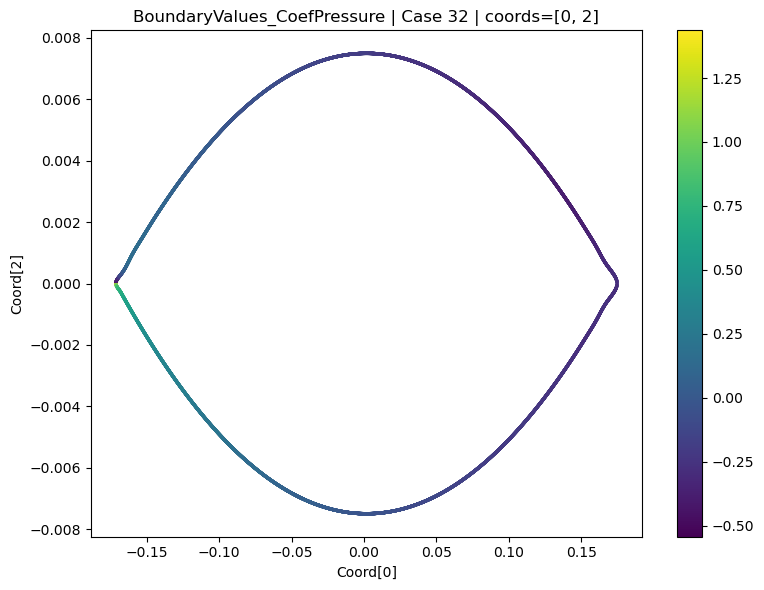

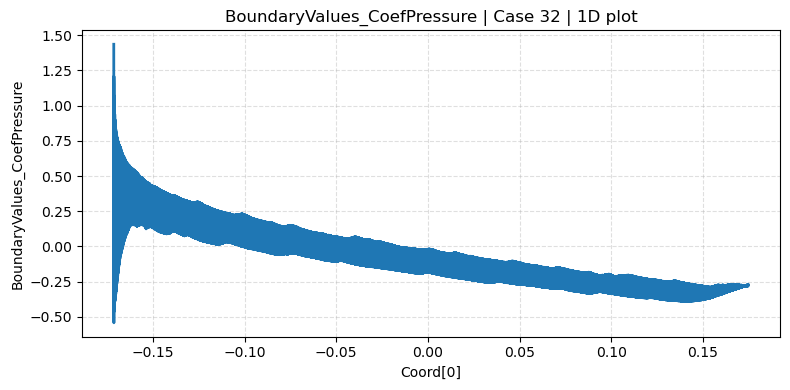

In [ ]:
from FotR import LEGOLAS
yourElf = LEGOLAS(db = db_completo)
yourElf.fields.plot_field(
    var_name = 'BoundaryValues_CoefPressure',
    case_idx = 32, group_key='CADGroup_3_completo',
    stage='0',
    coord_idx=[0, 2]
    )
yourElf.fields.plot_line_field(var_name = 'BoundaryValues_CoefPressure',
    case_idx = 32, group_key='CADGroup_3_completo', x_axis='coord')

In [ ]:
dict_stage_stats = db_completo.stats.stage_difference_stats(
    id_group='3_completo',
    stages=(0, 1),
    verbose=True    
)
SAM.DictVisualizer.rich_tree(dict_stage_stats)

In [ ]:
display(dict_stage_stats['0_vs_1']['global'])

In [ ]:
print(results)